In [20]:
import numpy as np
import time
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# Load data
data = fetch_california_housing()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------- WITHOUT PCA --------
start = time.time()

pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_no_pca.fit(X_train, y_train)
y_pred = pipe_no_pca.predict(X_test)

mse_before = mean_squared_error(y_test, y_pred)
time_no_pca = time.time() - start


# -------- WITH PCA (95%) --------
start = time.time()

pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('model', LinearRegression())
])

pipe_pca.fit(X_train, y_train)
y_pred_pca = pipe_pca.predict(X_test)

mse_after = mean_squared_error(y_test, y_pred_pca)
time_pca = time.time() - start

# Extract PCA info
pca_step = pipe_pca.named_steps['pca']

print("===== RESULTS =====")
print(f"Original features: {X.shape[1]}")
print(f"PCA components (95% variance): {pca_step.n_components_}")
print(f"Explained variance: {pca_step.explained_variance_ratio_.sum():.4f}")

print("\n--- Model Performance ---")
print(f"MSE before PCA: {mse_before:.4f}")
print(f"MSE after PCA:  {mse_after:.4f}")

print("\n--- Training Time ---")
print(f"Time without PCA: {time_no_pca:.4f} sec")
print(f"Time with PCA:    {time_pca:.4f} sec")


# -------- MULTIPLE PCA SETTINGS --------
components = [2, 4, 6, 8]
mse_list = []

for n in components:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n)),
        ('model', LinearRegression())
    ])

    pipe.fit(X_train, y_train)
    y_pred_n = pipe.predict(X_test)
    mse_list.append(mean_squared_error(y_test, y_pred_n))

print("\n--- PCA Component vs MSE ---")
for c, m in zip(components, mse_list):
    print(f"Components: {c}, MSE: {m:.4f}")

===== RESULTS =====
Original features: 8
PCA components (95% variance): 6
Explained variance: 0.9837

--- Model Performance ---
MSE before PCA: 0.5559
MSE after PCA:  0.6714

--- Training Time ---
Time without PCA: 0.0501 sec
Time with PCA:    0.0527 sec

--- PCA Component vs MSE ---
Components: 2, MSE: 1.2946
Components: 4, MSE: 0.7409
Components: 6, MSE: 0.6714
Components: 8, MSE: 0.5559


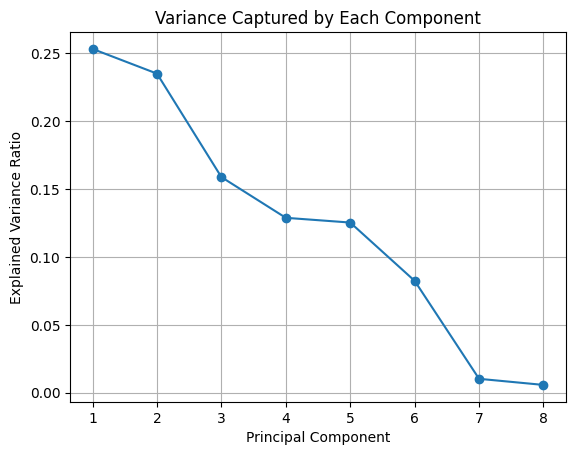

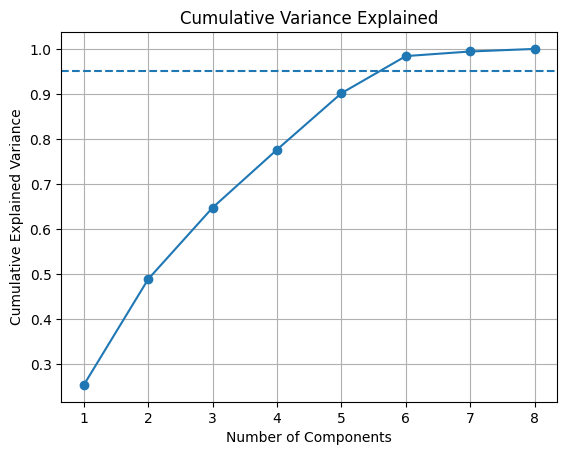

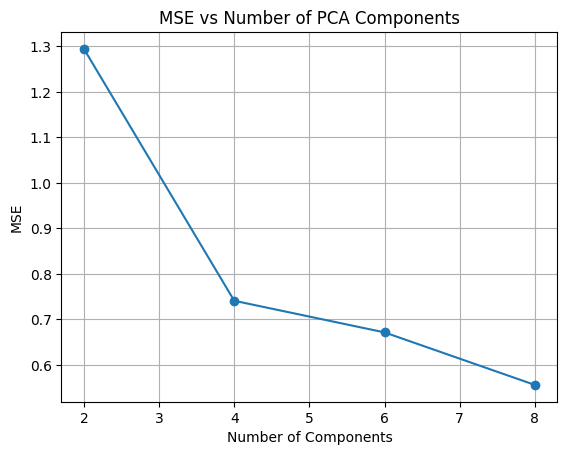

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale full data for visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# ---- Plot 1: Individual variance ----
plt.figure()
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Variance Captured by Each Component")
plt.grid()
plt.show()

# ---- Plot 2: Cumulative variance ----
plt.figure()
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained")
plt.axhline(y=0.95, linestyle='--')  # 95% threshold
plt.grid()
plt.show()

# ---- Plot 3: PCA components vs MSE ----
plt.figure()
plt.plot(components, mse_list, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("MSE")
plt.title("MSE vs Number of PCA Components")
plt.grid()
plt.show()